# Gunmen Dataset Sample Visualization

This notebook loads the Gunmen YOLO dataset from the project and visualizes one sample image with bounding boxes.

In [5]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from src.datasets import GunmenYoloDataset

In [6]:
dataset = GunmenYoloDataset(strict=False)
print(f"Samples: {len(dataset)}")
print(f"Class names: {dataset.class_names}")

Samples: 1309
Class names: ['Human', 'Gun']


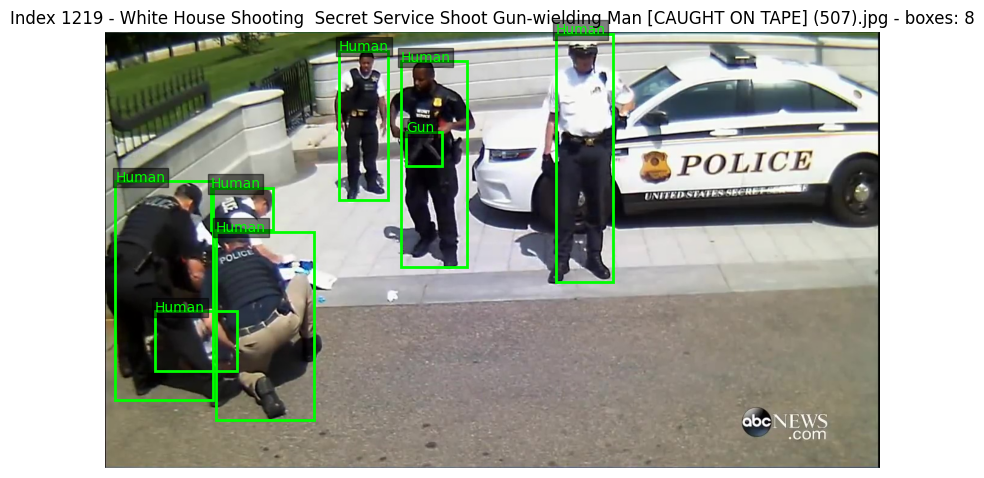

In [29]:
idx = random.randrange(len(dataset))
image, targets = dataset[idx]
image_path = dataset.get_sample_path(idx)

w, h = image.size
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(image)
ax.set_title(f"Index {idx} - {image_path.name} - boxes: {targets.shape[0]}")
ax.axis("off")

for row in targets:
    cls_id, x_c, y_c, bw, bh = row.tolist()
    x1 = (x_c - bw / 2.0) * w
    y1 = (y_c - bh / 2.0) * h
    box_w = bw * w
    box_h = bh * h

    rect = Rectangle(
        (x1, y1), box_w, box_h, linewidth=2, edgecolor="lime", facecolor="none"
    )
    ax.add_patch(rect)

    class_idx = int(cls_id)
    class_name = (
        dataset.class_names[class_idx]
        if class_idx < len(dataset.class_names)
        else f"class_{class_idx}"
    )
    ax.text(
        x1,
        y1,
        class_name,
        color="lime",
        fontsize=10,
        bbox={"facecolor": "black", "alpha": 0.5, "pad": 2},
    )

plt.show()

In [8]:
targets[:10]

tensor([[1.0000, 0.5215, 0.6014, 0.0305, 0.0417],
        [1.0000, 0.6180, 0.4243, 0.0406, 0.0542],
        [0.0000, 0.7359, 0.6319, 0.1312, 0.7194],
        [0.0000, 0.0797, 0.5424, 0.1469, 0.4708],
        [0.0000, 0.0508, 0.6285, 0.0953, 0.1597]])